##  Étape 0 _ Imports et configuration
**Ce qu'on fait :** Charger toutes les bibliothèques nécessaires et fixer le seed pour la reproductibilité.

In [849]:
# ── Bibliothèques standard ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time

warnings.filterwarnings('ignore')

# ── Machine Learning ────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import ADASYN
from scipy.sparse import issparse

# ── Deep Learning (PyTorch) ─────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# ── Reproductibilité ────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# ── Device (GPU si disponible, sinon CPU) ───────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device utilisé : {DEVICE}")
print(f" PyTorch version : {torch.__version__}")
print(f" Pandas version  : {pd.__version__}")

 Device utilisé : cpu
 PyTorch version : 2.12.0+cpu
 Pandas version  : 2.3.3


##  Étape 1 _ Chargement des datasets
**Ce qu'on fait :** Lire les 4 fichiers CSV et afficher leurs dimensions et colonnes.  
**Vérification :** On vérifie que chaque dataset est bien chargé et que la colonne cible existe.

In [850]:
# ── Chemins des fichiers ─────────────────────────────────────────
PATHS = {
    'bank' : 'data/Bank.csv',
    'news' : 'data/News.xlsx',
    'telecom' : 'data/Telecom.csv',
    'insurance' : 'data/Insurance.csv'
}

# ── Chargement ───────────────────────────────────────────────────
raw = {}
for name, path in PATHS.items():
    if os.path.exists(path):
        if path.endswith('.xlsx'):
            raw[name] = pd.read_excel(path)
        else :
            raw[name] = pd.read_csv(path)
        print(f" {name} -> {raw[name].shape[0]} lignes x {raw[name].shape[1]} colonnes")
    else :
        print(f" {name} -> fichier introuvable : {path}")

print()
# ── Aperçu rapide ────────────────────────────────────────────────
for name, df in raw.items():
    print(f"{'_'*190}")
    print(f"{name.upper()}_Colonnes :")
    print(list(df.columns))
    print(f" Types : {dict(df.dtypes.value_counts())}")
    print(f" Manquants : {df.isnull().sum().sum()} valeurs")

 bank -> 10000 lignes x 14 colonnes
 news -> 15855 lignes x 19 colonnes
 telecom -> 7043 lignes x 38 colonnes
 insurance -> 33908 lignes x 17 colonnes

______________________________________________________________________________________________________________________________________________________________________________________________
BANK_Colonnes :
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
 Types : {dtype('int64'): np.int64(9), dtype('O'): np.int64(3), dtype('float64'): np.int64(2)}
 Manquants : 0 valeurs
______________________________________________________________________________________________________________________________________________________________________________________________
NEWS_Colonnes :
['SubscriptionID', 'HH Income', 'Home Ownership', 'Ethnicity', 'dummy for Children', 'Year Of Residence', 'Age range', 'Language', 'Ad

##  Étape 2 _ Nettoyage des données
**Ce qu'on fait :** Pour chaque dataset :
1. Identifier et supprimer les colonnes inutiles (IDs, colonnes à fuites de données)
2. Supprimer les doublons
3. Gérer les valeurs manquantes
4. Unifier les expressions équivalentes
5. Créer la colonne cible binaire (0/1)

**Vérification :** On affiche la shape avant/après et le taux de churn.

In [851]:
# ════════════════════════════════════════════════════════════════
# NETTOYAGE BANK
# ════════════════════════════════════════════════════════════════
print("=" * 61)
print("NETTOYAGE DATASET BANK")
print("=" * 61)

df_bank = raw['bank'].copy()
print(f"Shape initiale : {df_bank.shape}") # Avant de nettoyage

# ── 1. Renommer la cible ──────────────────────────────────────────
df_bank.rename(columns={'Exited': 'Churn'}, inplace=True)

# ── 2. Supprimer colonnes inutiles ────────────────────────────────
cols_drop_bank = ['RowNumber', 'CustomerId', 'Surname']
df_bank.drop(columns=cols_drop_bank, inplace=True)
print(f"Après suppression colonnes inutiles : {df_bank.shape}")

# ── 3. Valeurs manquantes ─────────────────────────────────────────
df_bank.dropna(inplace=True)
df_bank.drop_duplicates(inplace=True)

print(f"Distribution cible : {dict(df_bank['Churn'].value_counts())}") # 1  et 0
print(f"Taux de churn : {df_bank['Churn'].mean()*100:.2f}%") 
print(f"Shape finale Bank : {df_bank.shape}")

NETTOYAGE DATASET BANK
Shape initiale : (10000, 14)
Après suppression colonnes inutiles : (10000, 11)
Distribution cible : {0: np.int64(7963), 1: np.int64(2037)}
Taux de churn : 20.37%
Shape finale Bank : (10000, 11)


In [852]:
# ════════════════════════════════════════════════════════════════
# NETTOYAGE NEWS
# ════════════════════════════════════════════════════════════════
print("=" * 100)
print("NETTOYAGE DATASET NEWS")
print("=" * 100)

df_news = raw['news'].copy()
print(f"Shape initiale : {df_news.shape}")
print(f"Colonnes : {list(df_news .columns)}")

# ── Identifier la colonne cible ──────────────────────────────────
# Selon l'article : colonne 'Subscriber'
df_news.rename(columns={'Subscriber': 'Churn'}, inplace=True)

# ── Supprimer colonnes géographiques et peu utiles ───────────────
cols_drop_news = ['Address','State','City','Country',
                  'Zip Code','Nielsen Prizm','Source Channel',
                  'Ethnicity','dummy for Children']
df_news.drop(columns=[c for c in cols_drop_news if c in df_news.columns], inplace=True)

# ── Nettoyage ────────────────────────────────────────────────────
df_news.dropna(inplace=True)
df_news.drop_duplicates(inplace=True)

print(f"Distribution cible : {dict(df_news['Churn'].value_counts())}")
# ── Convertir la cible en nombres ──────────────────────────────────
df_news['Churn'] = df_news['Churn'].map({'NO': 0, 'YES': 1})
print(f"Taux de churn : {df_news['Churn'].mean()*100:.2f}%")
print(f"Shape finale News : {df_news.shape}")

NETTOYAGE DATASET NEWS
Shape initiale : (15855, 19)
Colonnes : ['SubscriptionID', 'HH Income', 'Home Ownership', 'Ethnicity', 'dummy for Children', 'Year Of Residence', 'Age range', 'Language', 'Address', 'State', 'City', 'County', 'Zip Code', 'weekly fee', 'Deliveryperiod', 'Nielsen Prizm', 'reward program', 'Source Channel', 'Subscriber']
Distribution cible : {'NO': np.int64(11752), 'YES': np.int64(2827)}
Taux de churn : 19.39%
Shape finale News : (14579, 11)


In [853]:
# ════════════════════════════════════════════════════════════════
# NETTOYAGE TELECOM
# ════════════════════════════════════════════════════════════════
print("=" * 55)
print("NETTOYAGE DATASET TELECOM")
print("=" * 55)

df_tel = raw['telecom'].copy()
print(f"Shape initiale : {df_tel.shape}")

# ── 1. Supprimer les lignes 'Joined' (pas churn ni stayed) ───────
df_tel = df_tel[df_tel['Customer Status'] != 'Joined'] # Nouveaux arrivés n'ont pas d'historique de churn
print(f"Après suppression 'Joined' : {df_tel.shape}")

# ── 2. Créer la variable cible binaire ──────────────────────────
df_tel['Churn'] = (df_tel['Customer Status'] == 'Churned').astype(int) # 1 = churned et 0 = Stayed
print(f"Distribution cible : {dict(df_tel['Churn'].value_counts())}")
print(f"Taux de churn : {df_tel['Churn'].mean()*100:.2f}%")

# ── 3. Supprimer colonnes non pertinentes ────────────────────────
cols_drop_tel = [
    'Customer ID',        # identifiant unique -> pas prédictif
    'Customer Status',    # dérivée de la cible ->data leakage
    'Churn Category',     # info post-churn -> data leakage
    'Churn Reason',       # info post-churn -> data leakage
    'City',               # trop de modalités
    'Zip Code',           # géographique redondant
    'Latitude',           # géographique
    'Longitude',          # géographique
]
df_tel.drop(columns=[c for c in cols_drop_tel if c in df_tel.columns], inplace=True)
print(f"Après suppression colonnes inutiles : {df_tel.shape}")

# ── 4. Gérer les valeurs manquantes ──────────────────────────────
print(f"Valeurs manquantes avant : {df_tel.isnull().sum().sum()}")
# Colonnes numériques -> médiane
for col in df_tel.select_dtypes(include='number').columns:
    df_tel[col].fillna(df_tel[col].median())
# Colonnes texte -> 'Unknown'
for c in df_tel.select_dtypes(include='object').columns:
    df_tel[col].fillna('Unknown')
print(f"Valeurs manquantes après  : {df_tel.isnull().sum().sum()}")

# ── 5. Supprimer les doublons ─────────────────────────────────────
before = len(df_tel)
df_tel.drop_duplicates(inplace=True)
print(f"Doublons supprimés : {before - len(df_tel)}")
print(f"Shape finale Telecom : {df_tel.shape}")


NETTOYAGE DATASET TELECOM
Shape initiale : (7043, 38)
Après suppression 'Joined' : (6589, 38)
Distribution cible : {0: np.int64(4720), 1: np.int64(1869)}
Taux de churn : 28.37%
Après suppression colonnes inutiles : (6589, 31)
Valeurs manquantes avant : 18326
Valeurs manquantes après  : 18326
Doublons supprimés : 0
Shape finale Telecom : (6589, 31)


In [854]:
# ════════════════════════════════════════════════════════════════
# NETTOYAGE INSURANCE
# ════════════════════════════════════════════════════════════════
print("=" * 55)
print("NETTOYAGE DATASET INSURANCE")
print("=" * 55)

df_ins = raw['insurance'].copy()
print(f"Shape initiale : {df_ins.shape}")
print(f"Colonnes : {list(df_ins.columns)}")

# ── Identifier la colonne cible ──────────────────────────────────
# Dernière colonne = feature_15 (selon l'article)
target_col = df_ins.columns[-1] # Récupère le nom de la dernière colonne
print(f"colonne cible détectée : '{target_col}'")
df_ins.rename(columns={target_col: 'Churn'}, inplace=True)

# ── Nettoyage ────────────────────────────────────────────────────
df_ins.dropna(inplace=True)
df_ins.drop_duplicates(inplace=True)

# ── Vérification ─────────────────────────────────────────────────
print(f"Distribution cible : {dict(df_ins['Churn'].value_counts())}")
print(f"Taux de churn : {df_ins['Churn'].mean()*100:.2f}%")
print(f"Shape finale Insurance : {df_ins.shape}")

NETTOYAGE DATASET INSURANCE
Shape initiale : (33908, 17)
Colonnes : ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'labels']
colonne cible détectée : 'labels'
Distribution cible : {0: np.int64(29941), 1: np.int64(3967)}
Taux de churn : 11.70%
Shape finale Insurance : (33908, 17)


##  Étape 3 _ Encodage des variables catégorielles
**Ce qu'on fait :** Convertir les colonnes texte en valeurs numériques avec LabelEncoder.  
**Pourquoi :** Les réseaux de neurones ne peuvent pas traiter du texte directement.  
**Vérification :** On vérifie que toutes les colonnes sont numériques après encodage.

In [855]:
# Colonnes nominales -> OneHotEncoder (pas d'ordre artificiel)
NOMINAL_COLS = {
    'telecom'  : ['Offer', 'Payment Method', 'Internet Service'],
    'bank'     : ['Geography', 'Gender'],
    'insurance': [],   # déjà numériques
    'news'     : ['HH Income', 'Home Ownership', 'Language',
                  'Age range'],
}

# Colonnes ordinales -> LabelEncoder (ordre a un sens)
ORDINAL_COLS = {
    'telecom'  : ['Contract', 'Online Security', 'Online Backup',
                  'Device Protection Plan', 'Premium Tech Support',
                  'Streaming TV', 'Streaming Movies',
                  'Streaming Music', 'Unlimited Data',
                  'Paperless Billing', 'Multiple Lines',
                  'Phone Service'],
    'bank'     : [],
    'insurance': [],
    'news'     : [],
}

def encode_smart(df, dataset_name, name):
    """
    Encodage intelligent :
    - Colonnes nominales -> OneHotEncoder (évite l'ordre artificiel)
    - Colonnes ordinales -> LabelEncoder (l'ordre a un sens)
    - Colonnes binaires  -> LabelEncoder (0/1 direct)
    """
    df = df.copy()
    le = LabelEncoder()

    nominal = NOMINAL_COLS.get(dataset_name.lower(), [])
    ordinal = ORDINAL_COLS.get(dataset_name.lower(), [])

    encoded_dfs = [df.drop(columns=[c for c in nominal
                                     if c in df.columns
                                     and c != 'Churn'])]

    # OneHotEncoder pour colonnes nominales
    nominal_present = [c for c in nominal
                       if c in df.columns and c != 'Churn']
    if nominal_present:
        ohe = OneHotEncoder(sparse_output=False,
                            handle_unknown='ignore',
                            drop='first')
        ohe_arr = ohe.fit_transform(df[nominal_present])
        ohe_cols = ohe.get_feature_names_out(nominal_present)
        ohe_df   = pd.DataFrame(ohe_arr, columns=ohe_cols,
                                 index=df.index)
        encoded_dfs.append(ohe_df)

    df_enc = pd.concat(encoded_dfs, axis=1)

    # LabelEncoder pour toutes les colonnes object restantes
    for col in df_enc.columns:
        if col == 'Churn':
            continue
        if df_enc[col].dtype == 'object':
            df_enc[col] = le.fit_transform(
                df_enc[col].astype(str))

    print(f" {name:10s} -> {df_enc.shape[1]-1} features après encodage")
    return df_enc

# ── Appliquer l'encodage ─────────────────────────────────────────
print("ENCODAGE INTELLIGENT")
print("="*110)
df_bank = encode_dataset(df_bank, 'Bank')
df_news = encode_dataset(df_news, 'News')
df_tel  = encode_dataset(df_tel,  'Telecom')
df_ins  = encode_dataset(df_ins,  'Insurance')

ENCODAGE INTELLIGENT
 Bank -> 2 colonnes encodées : ['Geography', 'Gender']
 Toutes les colonnes sont numériques
 News -> 7 colonnes encodées : ['HH Income', 'Home Ownership', 'Age range', 'Language', 'County']...
 Toutes les colonnes sont numériques
 Telecom -> 18 colonnes encodées : ['Gender', 'Married', 'Offer', 'Phone Service', 'Multiple Lines']...
 Toutes les colonnes sont numériques
 Insurance -> 0 colonnes encodées : []
 Toutes les colonnes sont numériques


##  Étape 4 _ Sélection des features par heatmap de corrélation
**Ce qu'on fait :** Calculer la corrélation de chaque feature avec la cible 'Churn'.  
Supprimer les features dont la corrélation absolue est < seuil (comme dans l'article).  
**Pourquoi :** Réduire le bruit, éviter l'overfitting, réduire le temps d'entraînement.  
**Vérification :** On affiche la heatmap et le nombre de features retenues.


In [856]:
#  on garde plus de features (seuils réduits)
THRESHOLDS_FIXED = {
    'Telecom'  : 0.05,   
    'Bank'     : 0.01,  
    'Insurance': 0.03,   
    'News'     : 0.03,   
}

print("\nSÉLECTION FEATURES — SEUILS")
print("="*55)
df_tel  = select_features_by_correlation(
    df_tel,  'Telecom',   THRESHOLDS_FIXED['Telecom'],   plot=False)
df_bank = select_features_by_correlation(
    df_bank, 'Bank',      THRESHOLDS_FIXED['Bank'],      plot=False)
df_ins  = select_features_by_correlation(
    df_ins,  'Insurance', THRESHOLDS_FIXED['Insurance'], plot=False)
df_news = select_features_by_correlation(
    df_news, 'News',      THRESHOLDS_FIXED['News'],      plot=False)

print("\nRÉSUMÉ FEATURES ")
for name, df in [('Telecom',df_tel),('Bank',df_bank),
                  ('Insurance',df_ins),('News',df_news)]:
    print(f"  {name:12s} : {df.shape[1]-1} features retenues")


SÉLECTION FEATURES — SEUILS
──────────────────────────────────────────────────
 Telecom — Seuil = 0.05
   Features retenues (23) : ['Age', 'Married', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Offer']...
   Features supprimées (7) : ['Gender', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Type', 'Total Refunds']...
──────────────────────────────────────────────────
 Bank — Seuil = 0.01
   Features retenues (9) : ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance']...
   Features supprimées (1) : ['HasCrCard']
──────────────────────────────────────────────────
 Insurance — Seuil = 0.03
   Features retenues (13) : ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6']...
   Features supprimées (3) : ['feature_0', 'feature_10', 'feature_14']
──────────────────────────────────────────────────
 News — Seuil = 0.03
   Features retenues (8) : ['SubscriptionID', 'HH Income', 'Home Ownership', 'Y

##  Étape 5 _ Normalisation (StandardScaler)
**Ce qu'on fait :** Mettre toutes les features à la même échelle (mean=0, std=1).  
**Pourquoi :** Les réseaux de neurones convergent mieux avec des données normalisées.  
**Vérification :** On affiche la moyenne et l'écart-type avant/après.

In [857]:
HYPERPARAMS = {
    'Telecom'   : {'lstm_hidden': 64, 'cnn_hidden': 64,
                   'num_heads': 4,    'lr': 0.001},
    'Bank'      : {'lstm_hidden': 64, 'cnn_hidden': 64,
                   'num_heads': 4,    'lr': 0.001},
    'Insurance' : {'lstm_hidden': 64, 'cnn_hidden': 64,
                   'num_heads': 4,    'lr': 0.001},
    'News'      : {'lstm_hidden': 64, 'cnn_hidden': 64,
                   'num_heads': 4,    'lr': 0.001},
}

# ── NaN Telecom : valeurs manquantes restantes ───────────────
print("VÉRIFICATION NaN avant normalisation")
print("="*55)
for name, df in [('Telecom',df_tel),('Bank',df_bank),
                  ('Insurance',df_ins),('News',df_news)]:
    nan_count = df.isnull().sum().sum()
    print(f"  {name:12s} : {nan_count} NaN")
    if nan_count > 0:
        # Colonnes numériques -> médiane
        for col in df.select_dtypes(include='number').columns:
            if col != 'Churn':
                df[col].fillna(df[col].median(), inplace=True)
        # Colonnes objet -> mode
        for col in df.select_dtypes(include='object').columns:
            if col != 'Churn':
                df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"  -> NaN corrigés ")

# Vérifier si Churn est bien 0/1
print("\nVérification colonne Churn :")
for name, df in [('Telecom',df_tel),('Bank',df_bank),
                  ('Insurance',df_ins),('News',df_news)]:
    unique_vals = df['Churn'].unique()
    print(f"  {name:12s} : {unique_vals[:5]}")
    # Convertir en 0/1 si nécessaire
    if df['Churn'].dtype == 'object':
        df['Churn'] = (df['Churn'].str.upper().isin(
            ['YES','1','TRUE','CHURNED'])).astype(int)
        print(f"  -> Converti en 0/1 ")

# ── Normalisation  ────────────────────────────────────────
print("\nNORMALISATION STANDARDSCALER")
print("="*55)

def normalize_safe(df, name):
    """Normalisation avec vérification NaN."""
    X = df.drop('Churn', axis=1).values.astype(np.float32)
    y = df['Churn'].values.astype(np.float32)

    # Remplacer NaN/Inf résiduels
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    print(f"  {name:12s} -> NaN restants : {np.isnan(X).sum()}")

    scaler  = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print(f"  {name:12s} -> mean={X_scaled.mean():.4f} "
          f"std={X_scaled.std():.4f} shape={X_scaled.shape}")
    return X_scaled.astype(np.float32), y, scaler

X_tel,  y_tel,  scaler_tel  = normalize_safe(df_tel,  'Telecom')
X_bank, y_bank, scaler_bank = normalize_safe(df_bank, 'Bank')
X_ins,  y_ins,  scaler_ins  = normalize_safe(df_ins,  'Insurance')
X_news, y_news, scaler_news = normalize_safe(df_news, 'News')

print("\n Normalisation terminée — vérifiez 0 NaN ci-dessus")

# ── Vérification finale avant entraînement ───────────────────────
print("\nVÉRIFICATION FINALE")
print("="*55)
for name, X, y in [('Telecom',   X_tel,  y_tel),
                   ('Bank',      X_bank, y_bank),
                   ('Insurance', X_ins,  y_ins),
                   ('News',      X_news, y_news)]:
    nan_x = np.isnan(X).sum()
    nan_y = np.isnan(y).sum()
    print(f"  {name:12s} : shape={X.shape} | "
          f"NaN_X={nan_x} | NaN_y={nan_y} | "
          f"churn={y.mean()*100:.1f}%")
    if nan_x > 0 or nan_y > 0:
        print(f"   NaN détectés — correction forcée")
        X = np.nan_to_num(X, nan=0.0)
        y = np.nan_to_num(y, nan=0.0)

VÉRIFICATION NaN avant normalisation
  Telecom      : 1344 NaN
  -> NaN corrigés 
  Bank         : 0 NaN
  Insurance    : 0 NaN
  News         : 0 NaN

Vérification colonne Churn :
  Telecom      : [0 1]
  Bank         : [1 0]
  Insurance    : [1 0]
  News         : [0 1]

NORMALISATION STANDARDSCALER
  Telecom      -> NaN restants : 0
  Telecom      -> mean=0.0000 std=1.0000 shape=(6589, 23)
  Bank         -> NaN restants : 0
  Bank         -> mean=-0.0000 std=1.0000 shape=(10000, 9)
  Insurance    -> NaN restants : 0
  Insurance    -> mean=0.0000 std=1.0000 shape=(33908, 13)
  News         -> NaN restants : 0
  News         -> mean=0.0000 std=1.0000 shape=(14579, 8)

 Normalisation terminée — vérifiez 0 NaN ci-dessus

VÉRIFICATION FINALE
  Telecom      : shape=(6589, 23) | NaN_X=0 | NaN_y=0 | churn=28.4%
  Bank         : shape=(10000, 9) | NaN_X=0 | NaN_y=0 | churn=20.4%
  Insurance    : shape=(33908, 13) | NaN_X=0 | NaN_y=0 | churn=11.7%
  News         : shape=(14579, 8) | NaN_X=0 |

##  Étape 6 — Équilibrage des classes avec ADASYN
**Ce qu'on fait :** Générer des échantillons synthétiques pour la classe minoritaire (churn).  
**Pourquoi :** Tous les datasets ont un déséquilibre (11% à 27% de churn) — sans correction, le modèle prédit toujours "non-churn".  
**ADASYN vs SMOTE :** ADASYN génère plus d'échantillons proches des frontières de décision -> meilleure discrimination.  
**Vérification :** Distribution avant/après -> visualisation.


In [ ]:
HYPERPARAMS = {
    'Telecom'   : {'lstm_hidden': 64, 'cnn_hidden': 64,
                   'num_heads': 4,    'lr': 0.001},
    'Bank'      : {'lstm_hidden': 64, 'cnn_hidden': 64,
                   'num_heads': 4,    'lr': 0.001},
    'Insurance' : {'lstm_hidden': 64, 'cnn_hidden': 64,
                   'num_heads': 4,    'lr': 0.001},
    'News'      : {'lstm_hidden': 64, 'cnn_hidden': 64,
                   'num_heads': 4,    'lr': 0.001},
}

# ── NaN Telecom : valeurs manquantes restantes ───────────────
print("VÉRIFICATION NaN avant normalisation")
print("="*55)
for name, df in [('Telecom',df_tel),('Bank',df_bank),
                  ('Insurance',df_ins),('News',df_news)]:
    nan_count = df.isnull().sum().sum()
    print(f"  {name:12s} : {nan_count} NaN")
    if nan_count > 0:
        # Colonnes numériques -> médiane
        for col in df.select_dtypes(include='number').columns:
            if col != 'Churn':
                df[col].fillna(df[col].median(), inplace=True)
        # Colonnes objet -> mode
        for col in df.select_dtypes(include='object').columns:
            if col != 'Churn':
                df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"  -> NaN corrigés ")

# Vérifier si Churn est bien 0/1
print("\nVérification colonne Churn :")
for name, df in [('Telecom',df_tel),('Bank',df_bank),
                  ('Insurance',df_ins),('News',df_news)]:
    unique_vals = df['Churn'].unique()
    print(f"  {name:12s} : {unique_vals[:5]}")
    # Convertir en 0/1 si nécessaire
    if df['Churn'].dtype == 'object':
        df['Churn'] = (df['Churn'].str.upper().isin(
            ['YES','1','TRUE','CHURNED'])).astype(int)
        print(f"  -> Converti en 0/1 ")

# ── Normalisation corrigée ────────────────────────────────────────
print("\nNORMALISATION STANDARDSCALER")
print("="*55)

def normalize_safe(df, name):
    """Normalisation avec vérification NaN."""
    X = df.drop('Churn', axis=1).values.astype(np.float32)
    y = df['Churn'].values.astype(np.float32)

    # Remplacer NaN/Inf résiduels
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    print(f"  {name:12s} -> NaN restants : {np.isnan(X).sum()}")

    scaler  = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print(f"  {name:12s} -> mean={X_scaled.mean():.4f} "
          f"std={X_scaled.std():.4f} shape={X_scaled.shape}")
    return X_scaled.astype(np.float32), y, scaler

X_tel,  y_tel,  scaler_tel  = normalize_safe(df_tel,  'Telecom')
X_bank, y_bank, scaler_bank = normalize_safe(df_bank, 'Bank')
X_ins,  y_ins,  scaler_ins  = normalize_safe(df_ins,  'Insurance')
X_news, y_news, scaler_news = normalize_safe(df_news, 'News')

print("\n Normalisation terminée — vérifiez 0 NaN ci-dessus")

# ── Vérification finale avant entraînement ───────────────────────
print("\nVÉRIFICATION FINALE")
print("="*55)
for name, X, y in [('Telecom',   X_tel,  y_tel),
                   ('Bank',      X_bank, y_bank),
                   ('Insurance', X_ins,  y_ins),
                   ('News',      X_news, y_news)]:
    nan_x = np.isnan(X).sum()
    nan_y = np.isnan(y).sum()
    print(f"  {name:12s} : shape={X.shape} | "
          f"NaN_X={nan_x} | NaN_y={nan_y} | "
          f"churn={y.mean()*100:.1f}%")
    if nan_x > 0 or nan_y > 0:
        print(f"   NaN détectés — correction forcée")
        X = np.nan_to_num(X, nan=0.0)
        y = np.nan_to_num(y, nan=0.0)

VÉRIFICATION NaN avant normalisation
  Telecom      : 0 NaN
  Bank         : 0 NaN
  Insurance    : 0 NaN
  News         : 0 NaN

Vérification colonne Churn :
  Telecom      : [0 1]
  Bank         : [1 0]
  Insurance    : [1 0]
  News         : [0 1]

NORMALISATION STANDARDSCALER
  Telecom      → NaN restants : 0
  Telecom      → mean=0.0000 std=1.0000 shape=(6589, 23)
  Bank         → NaN restants : 0
  Bank         → mean=-0.0000 std=1.0000 shape=(10000, 9)
  Insurance    → NaN restants : 0
  Insurance    → mean=0.0000 std=1.0000 shape=(33908, 13)
  News         → NaN restants : 0
  News         → mean=0.0000 std=1.0000 shape=(14579, 8)

 Normalisation terminée — vérifiez 0 NaN ci-dessus

VÉRIFICATION FINALE
  Telecom      : shape=(6589, 23) | NaN_X=0 | NaN_y=0 | churn=28.4%
  Bank         : shape=(10000, 9) | NaN_X=0 | NaN_y=0 | churn=20.4%
  Insurance    : shape=(33908, 13) | NaN_X=0 | NaN_y=0 | churn=11.7%
  News         : shape=(14579, 8) | NaN_X=0 | NaN_y=0 | churn=19.4%


##  Étape 7 _ Architecture CCP-Net (code de l'article)
**Ce qu'on fait :** Définir les 3 modules de CCP-Net :
1. `MultiHeadSelfAttention` — capture les dépendances globales
2. `BiLSTM` — capture les tendances temporelles
3. `CCPNet` — assemble les 3 modules + Sigmoid pour prédire churn/non-churn


In [859]:
# ════════════════════════════════════════════════════════════════
# MODULE 1 : Multi-Head Self-Attention
# ════════════════════════════════════════════════════════════════
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, input_dim, output_dim, num_heads):
        super(MultiHeadSelfAttention, self).__init__()
        self.num_heads  = num_heads
        self.output_dim = output_dim
        
        # 3 projections linéaires pour Q, K, V
        self.query_linear = nn.Linear(input_dim, output_dim)
        self.key_linear   = nn.Linear(input_dim, output_dim)
        self.value_linear = nn.Linear(input_dim, output_dim)
        
        # Projection finale + normalisation résiduelle
        self.final_linear = nn.Linear(output_dim, output_dim)
        self.layer_norm   = nn.LayerNorm(output_dim)

        #  projection résiduelle si input_dim différent output_dim
        if input_dim != output_dim:
            self.residual_proj = nn.Linear(input_dim, output_dim)
        else:
            self.residual_proj = None

    def forward(self, x):
        batch_size, seq_length, _ = x.size()
        
        # Projection Q, K, V
        queries = self.query_linear(x)
        keys    = self.key_linear(x)
        values  = self.value_linear(x)
        
        # Découpage multi-têtes : (batch, seq, heads, dim/heads)
        queries = queries.view(batch_size, seq_length, self.num_heads, self.output_dim // self.num_heads)
        keys    = keys.view(batch_size, seq_length, self.num_heads, self.output_dim // self.num_heads)
        values  = values.view(batch_size, seq_length, self.num_heads, self.output_dim // self.num_heads)
        
        # Permuter pour calcul attention : (batch, heads, seq, dim)
        queries = queries.permute(0, 2, 1, 3)
        keys    = keys.permute(0, 2, 1, 3)
        values  = values.permute(0, 2, 1, 3)
        
        # Score d'attention : Softmax(QK^T / sqrt(dk))
        attention_scores  = torch.matmul(queries, keys.transpose(-1, -2)) / (self.output_dim ** 0.5)
        attention_weights = F.softmax(attention_scores, dim=-1)
        attention_output  = torch.matmul(attention_weights, values)
        
        # Recombiner les têtes
        attention_output = attention_output.permute(0, 2, 1, 3).contiguous()
        attention_output = attention_output.view(batch_size, seq_length, self.output_dim)
        
        # Connexion résiduelle + LayerNorm (évite gradient vanishing)
        residual = self.residual_proj(x) if self.residual_proj is not None else x
        attention_output = self.layer_norm(attention_output + residual)

        return self.final_linear(attention_output)


# ════════════════════════════════════════════════════════════════
# MODULE 2 : BiLSTM
# ════════════════════════════════════════════════════════════════
class BiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=1):
        super(BiLSTM, self).__init__()
        # bidirectional=True -> lit la séquence dans les 2 sens
        self.lstm = nn.LSTM(input_dim, hidden_dim,
                            num_layers=num_layers,
                            bidirectional=True,
                            batch_first=True)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # Output shape : (batch, seq, hidden*2)
        return lstm_out


# ════════════════════════════════════════════════════════════════
# MODULE 3 : CCP-Net complet
# ════════════════════════════════════════════════════════════════
class CCPNet(nn.Module):
    def __init__(self, input_dim, lstm_hidden_dim, cnn_hidden_dim, output_dim, num_heads):
        super(CCPNet, self).__init__()

        # Bloc 1 : Attention (input_dim -> lstm_hidden_dim)
        self.attention = MultiHeadSelfAttention(input_dim, lstm_hidden_dim, num_heads)

        # Bloc 2 : BiLSTM (lstm_hidden_dim -> lstm_hidden_dim*2)
        self.bilstm = BiLSTM(lstm_hidden_dim, lstm_hidden_dim)

        #  fc_layer prend (lstm_hidden_dim*2) en entrée
        self.fc_layer = nn.Linear(lstm_hidden_dim * 2, cnn_hidden_dim)

        # Bloc 3 : CNN 1D
        self.cnn1 = nn.Conv1d(cnn_hidden_dim, cnn_hidden_dim, kernel_size=5, padding=2)
        self.cnn2 = nn.Conv1d(cnn_hidden_dim, output_dim,     kernel_size=3, padding=1)

        # Couche de sortie
        self.fc = nn.Linear(output_dim, output_dim)

    def forward(self, x):
        # x : (batch, seq=1, input_dim)

        # 1. Attention -> (batch, seq, lstm_hidden_dim)
        attention_out = self.attention(x)

        # 2. BiLSTM -> (batch, seq, lstm_hidden_dim*2)
        lstm_out = self.bilstm(attention_out)

        # 3. FC : appliquer sur la dernière dimension directement
        # lstm_out : (batch, seq, lstm_hidden*2)
        fc_out = self.fc_layer(lstm_out)          # (batch, seq, cnn_hidden_dim)

        # 4. Permuter pour CNN1d : (batch, channels, seq)
        fc_out = fc_out.permute(0, 2, 1)          # (batch, cnn_hidden_dim, seq)

        # 5. CNN
        cnn_out1 = F.relu(self.cnn1(fc_out))      # (batch, cnn_hidden_dim, seq)
        cnn_out2 = F.relu(self.cnn2(cnn_out1))    # (batch, output_dim, seq)

        # 6. Global Average Pooling + FC finale
        output = self.fc(cnn_out2.mean(dim=2))    # (batch, output_dim)

        return output


# ── Test rapide du forward pass ──────────────────────────────────
print("TEST FORWARD PASS CCP-Net")
print("="*55)
test_input = torch.randn(32, 1, 13)  # batch=32, seq=1, features=13
model_test = CCPNet(input_dim=13, lstm_hidden_dim=64,
                    cnn_hidden_dim=128, output_dim=1, num_heads=4)
test_out = model_test(test_input)
print(f" Input shape  : {test_input.shape}")
print(f" Output shape : {test_out.shape}  <- doit être (32, 1)")
print(f" Paramètres   : {sum(p.numel() for p in model_test.parameters()):,}")

TEST FORWARD PASS CCP-Net
 Input shape  : torch.Size([32, 1, 13])
 Output shape : torch.Size([32, 1])  <- doit être (32, 1)
 Paramètres   : 173,379


##  Étape 8 — Entraînement avec 10-fold Cross-Validation
**Ce qu'on fait :**
1. Diviser les données en 10 folds
2. Sur chaque fold : entraîner CCP-Net, valider, calculer les métriques
3. Appliquer Early Stopping (arrêt si val_loss ne s'améliore pas)
4. Calculer la moyenne des métriques sur les 10 folds

**Hyperparamètres (selon l'article) :**
- Optimizer : Adam (lr=0.001)
- Loss : BCEWithLogitsLoss
- Epochs max : 100
- Batch size : 32
- Early stopping patience : 10


In [860]:
# ── Hyperparamètres ──────────────────────────────────────────────
HYPERPARAMS = {
    'telecom'   : {'lstm_hidden': 64,  'cnn_hidden': 128, 'num_heads': 4,  'lr': 0.001},
    'bank'      : {'lstm_hidden': 64,  'cnn_hidden': 256, 'num_heads': 8,  'lr': 0.001},
    'insurance' : {'lstm_hidden': 128, 'cnn_hidden': 128, 'num_heads': 32, 'lr': 0.001},
    'news'      : {'lstm_hidden': 128, 'cnn_hidden': 128, 'num_heads': 16, 'lr': 0.001},
}

def train_one_fold(model, train_loader, val_loader, lr, epochs=100, patience=10):
    """Entraîne le modèle sur un fold avec Early Stopping."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) #  ajuste les poids du réseau
    criterion = nn.BCEWithLogitsLoss() #  fonction de perte pour classification binaire
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        # ── Phase entraînement ─────────────────────────────────────
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE) # Envoie sur GPU/CPU
            y_batch = y_batch.to(DEVICE)
            
            optimizer.zero_grad() # Réinitialise les gradients
            output = model(X_batch) # Forward pass : prédiction
            loss   = criterion(output, y_batch)  #  Calcule l'erreur
            loss.backward() # Backpropagation : calcule les gradients
            optimizer.step() # Met à jour les poids
            train_loss += loss.item() # Accumule la perte
        
        # ── Phase validation ───────────────────────────────────────
        model.eval() # Mode évaluation (désactive dropout)
        val_loss = 0.0
        with torch.no_grad(): # Désactive le calcul des gradients (économie mémoire)
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                output   = model(X_batch)
                loss     = criterion(output, y_batch)
                val_loss += loss.item()
        
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        
        # ── Early Stopping ─────────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    
    # Restaurer le meilleur état
    model.load_state_dict(best_state) # Recharge les meilleurs poids
    return model, train_losses, val_losses


def evaluate_model(model, loader):
    """Calcule les métriques sur un loader."""
    model.eval() # Mode évaluation
    all_preds, all_labels = [], [] # Listes pour stocker prédictions et vraies valeurs
    
    with torch.no_grad():  # Pas de calcul de gradients
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            output  = model(X_batch) # Forward pass
            probs   = torch.sigmoid(output).cpu().numpy().flatten() # Convertit en probabilités (0-1)
            preds   = (probs >= 0.5).astype(int)
            all_preds.extend(preds) # Ajoute les prédictions
            all_labels.extend(y_batch.numpy().flatten().astype(int)) # Ajoute les vraies valeurs
    
    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds, zero_division=0)
    f1   = f1_score(all_labels, all_preds, zero_division=0)
    
    return acc, prec, rec, f1, all_labels, all_preds


def run_kfold_ccpnet(X, y, dataset_name, n_splits=10, epochs=100, batch_size=32):
    """Entraîne CCP-Net avec 10-fold cross-validation."""
    
    hp = HYPERPARAMS[dataset_name.lower()]
    input_dim = X.shape[1]
    
    print(f"{'='*55}")
    print(f" {dataset_name} — CCP-Net 10-fold CV")
    print(f"   Samples: {len(X)} | Features: {input_dim} | Heads: {hp['num_heads']}")
    print(f"{'='*55}")
    
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    
    fold_metrics = {'acc':[], 'prec':[], 'rec':[], 'f1':[]}
    all_train_losses, all_val_losses = [], []
    
    for train_idx, val_idx in kfold.split(X, y):
        
        # ── Préparer les données du fold ───────────────────────────
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Reshape pour CCP-Net : (N, seq=1, features)
        X_tr_t = torch.FloatTensor(X_train).unsqueeze(1)
        X_vl_t = torch.FloatTensor(X_val).unsqueeze(1)
        y_tr_t = torch.FloatTensor(y_train).unsqueeze(1)
        y_vl_t = torch.FloatTensor(y_val).unsqueeze(1)
        
        train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                                  batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(TensorDataset(X_vl_t, y_vl_t),
                                  batch_size=batch_size, shuffle=False)
        
        # ── Créer le modèle ────────────────────────────────────────
        model = CCPNet(
            input_dim      = input_dim,
            lstm_hidden_dim= hp['lstm_hidden'],
            cnn_hidden_dim = hp['cnn_hidden'],
            output_dim     = 1,
            num_heads      = hp['num_heads']
        ).to(DEVICE)
        
        # ── Entraîner ─────────────────────────────────────────────
        t0 = time.time()
        model, t_losses, v_losses = train_one_fold(
            model, train_loader, val_loader, hp['lr'], epochs)
        elapsed = time.time() - t0
        
        # ── Évaluer ───────────────────────────────────────────────
        acc, prec, rec, f1, _, _ = evaluate_model(model, val_loader)
        fold_metrics['acc'].append(acc)
        fold_metrics['prec'].append(prec)
        fold_metrics['rec'].append(rec)
        fold_metrics['f1'].append(f1)
        all_train_losses.append(t_losses)
        all_val_losses.append(v_losses)
        
        print(f"  Fold {fold+1:2d}/{n_splits} | "
              f"Acc={acc*100:.2f}% | "
              f"Prec={prec*100:.2f}% | "
              f"Rec={rec*100:.2f}% | "
              f"F1={f1*100:.2f}% | "
              f"{elapsed:.1f}s")
    
    # ── Résultats moyens ──────────────────────────────────────────
    print(f"{'─'*55}")
    print(f"  MOYENNE  | "
          f"Acc={np.mean(fold_metrics['acc'])*100:.2f}% | "
          f"Prec={np.mean(fold_metrics['prec'])*100:.2f}% | "
          f"Rec={np.mean(fold_metrics['rec'])*100:.2f}% | "
          f"F1={np.mean(fold_metrics['f1'])*100:.2f}%")
    
    return fold_metrics, all_train_losses, all_val_losses, model

## Étape 9 _ Lancement de l'entraînement sur les 4 datasets
**Ce qu'on fait :** Exécuter le 5-fold CV sur chaque dataset et stocker les résultats.  

In [861]:
HYPERPARAMS = {
    'Telecom'   : {'lstm_hidden': 64, 'cnn_hidden': 64,
                   'num_heads': 4,    'lr': 0.001},
    'Bank'      : {'lstm_hidden': 64, 'cnn_hidden': 64,
                   'num_heads': 4,    'lr': 0.001},
}

#  Vérification immédiate
print("HYPERPARAMS chargé :", list(HYPERPARAMS.keys()))


def run_kfold_corrected(X, y, name, n_splits=5,
                        max_samples=5000, epochs=30,
                        batch_size=128):

    #  Vérification clé
    if name not in HYPERPARAMS:
        raise KeyError(
            f"'{name}' absent de HYPERPARAMS.\n"
            f"Clés disponibles : {list(HYPERPARAMS.keys())}\n"
            f"Vérifiez les majuscules.")

    hp        = HYPERPARAMS[name]
    input_dim = X.shape[1]

    # Sous-échantillonnage stratifié
    if len(X) > max_samples:
        from sklearn.model_selection import train_test_split
        X, _, y, _ = train_test_split(
            X, y, train_size=max_samples,
            stratify=y, random_state=SEED)
        print(f"   Réduit à {max_samples} samples")

    print(f"\n{'='*55}")
    print(f" {name} | {len(X)} samples | {input_dim} features")
    print(f"   ADASYN dans le fold — No Data Leakage")
    print(f"{'='*55}")

    kf  = StratifiedKFold(n_splits=n_splits,
                          shuffle=True, random_state=SEED)
    met = {'acc':[], 'prec':[], 'rec':[], 'f1':[]}
    t_all, v_all = [], []

    for fold, (tr_idx, vl_idx) in enumerate(kf.split(X, y)):

        X_tr_raw = X[tr_idx]
        y_tr_raw = y[tr_idx]
        X_val    = X[vl_idx]
        y_val    = y[vl_idx]

        #  ADASYN uniquement sur train du fold
        try:
            ada = ADASYN(random_state=SEED, n_neighbors=5)
            X_tr_res, y_tr_res = ada.fit_resample(
                X_tr_raw, y_tr_raw)
        except Exception as e:
            print(f"   ADASYN fold {fold+1} -> orig ({e})")
            X_tr_res = X_tr_raw
            y_tr_res = y_tr_raw

        Xtr = torch.FloatTensor(X_tr_res).unsqueeze(1)
        ytr = torch.FloatTensor(y_tr_res).unsqueeze(1)
        Xvl = torch.FloatTensor(X_val).unsqueeze(1)
        yvl = torch.FloatTensor(y_val).unsqueeze(1)

        tr_ld = DataLoader(TensorDataset(Xtr, ytr),
                           batch_size=batch_size,
                           shuffle=True, drop_last=True)
        vl_ld = DataLoader(TensorDataset(Xvl, yvl),
                           batch_size=batch_size,
                           shuffle=False)

        model = CCPNetV2(
            input_dim       = input_dim,
            lstm_hidden_dim = hp['lstm_hidden'],
            cnn_hidden_dim  = hp['cnn_hidden'],
            output_dim      = 1,
            num_heads       = hp['num_heads'],
            dropout         = 0.3
        )

        opt  = torch.optim.Adam(model.parameters(),
                                 lr=hp['lr'],
                                 weight_decay=1e-4)
        sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                   opt, mode='min', factor=0.5, patience=3)
        crit = nn.BCEWithLogitsLoss()

        best_loss, best_state = float('inf'), None
        patience_c = 0
        t_losses, v_losses = [], []
        t0 = time.time()

        for epoch in range(epochs):
            model.train()
            tl = 0.0
            for Xb, yb in tr_ld:
                opt.zero_grad()
                loss = crit(model(Xb), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), max_norm=1.0)
                opt.step()
                tl += loss.item()
            tl /= len(tr_ld)

            model.eval()
            vl = 0.0
            with torch.no_grad():
                for Xb, yb in vl_ld:
                    vl += crit(model(Xb), yb).item()
            vl /= len(vl_ld)

            t_losses.append(tl)
            v_losses.append(vl)
            sch.step(vl)

            if vl < best_loss:
                best_loss  = vl
                best_state = {k: v.clone() for k, v in
                              model.state_dict().items()}
                patience_c = 0
            else:
                patience_c += 1
                if patience_c >= 6:
                    break

        elapsed = time.time() - t0
        model.load_state_dict(best_state)

        acc, prec, rec, f1, _, _ = evaluate_model(model, vl_ld)
        met['acc'].append(acc)
        met['prec'].append(prec)
        met['rec'].append(rec)
        met['f1'].append(f1)
        t_all.append(t_losses)
        v_all.append(v_losses)

        print(f"  Fold {fold+1}/{n_splits} | "
              f"Acc={acc*100:.2f}% | "
              f"Prec={prec*100:.2f}% | "
              f"Rec={rec*100:.2f}% | "
              f"F1={f1*100:.2f}% | "
              f"Ep={len(t_losses)} | "
              f"{elapsed:.0f}s")

    print(f"{'─'*55}")
    print(f"  MOY -> "
          f"Acc={np.mean(met['acc'])*100:.2f}% | "
          f"Prec={np.mean(met['prec'])*100:.2f}% | "
          f"Rec={np.mean(met['rec'])*100:.2f}% | "
          f"F1={np.mean(met['f1'])*100:.2f}%")

    return met, t_all, v_all, model


# ── Lancement ─────────────────────────────────────────────────────
RESULTS = {}

for name, X, y in [('Telecom',   X_tel,  y_tel),
                   ('Bank',      X_bank, y_bank)]:

    met, tl, vl, model = run_kfold_corrected(
        X, y, name,
        n_splits    = 5,
        max_samples = 5000,
        epochs      = 30,
        batch_size  = 128
    )

    RESULTS[name] = {
        'metrics' : met,
        'model'   : model,
        't_losses': tl,
        'v_losses': vl,
    }
    torch.save(model.state_dict(),
               f'models/best_model_{name.lower()}.pth')
    print(f" best_model_{name.lower()}.pth\n")

print(" Entraînement terminé !")

HYPERPARAMS chargé : ['Telecom', 'Bank']


   Réduit à 5000 samples

 Telecom | 5000 samples | 23 features
   ADASYN dans le fold — No Data Leakage
  Fold 1/5 | Acc=78.10% | Prec=57.27% | Rec=90.14% | F1=70.04% | Ep=16 | 11s
  Fold 2/5 | Acc=78.40% | Prec=57.76% | Rec=89.08% | F1=70.08% | Ep=13 | 12s
  Fold 3/5 | Acc=84.70% | Prec=70.40% | Rec=79.58% | F1=74.71% | Ep=30 | 25s
  Fold 4/5 | Acc=85.50% | Prec=71.17% | Rec=81.98% | F1=76.19% | Ep=30 | 23s
  Fold 5/5 | Acc=76.00% | Prec=54.45% | Rec=92.93% | F1=68.67% | Ep=18 | 17s
───────────────────────────────────────────────────────
  MOY -> Acc=80.54% | Prec=62.21% | Rec=86.74% | F1=71.94%
 best_model_telecom.pth

   Réduit à 5000 samples

 Bank | 5000 samples | 9 features
   ADASYN dans le fold — No Data Leakage
  Fold 1/5 | Acc=80.90% | Prec=52.29% | Rec=67.49% | F1=58.92% | Ep=18 | 17s
  Fold 2/5 | Acc=71.50% | Prec=40.52% | Rec=84.80% | F1=54.83% | Ep=16 | 18s
  Fold 3/5 | Acc=81.10% | Prec=52.77% | Rec=70.10% | F1=60.21% | Ep=30 | 28s
  Fold 4/5 | Acc=78.80% | Prec=48.58% 

In [862]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
import numpy as np
import time

# ── CONFIGURATION DU DEVICE ET DU SEED ────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
print(f" Initialisation — Device actif : {device.type.upper()} | Seed : {SEED}")

# Dictionnaire d'hyperparamètres stabilisés
HYPERPARAMS_FIX = {
    'insurance' : {'lstm_hidden': 64, 'cnn_hidden': 64, 'num_heads': 4, 'lr': 0.0005},
    'news'      : {'lstm_hidden': 64, 'cnn_hidden': 64, 'num_heads': 4, 'lr': 0.0005},
}

def get_class_weights_smooth(y):
    """Calcule les poids d'équilibre adoucis grâce à la racine carrée."""
    n_neg = (y == 0).sum()
    n_pos = (y == 1).sum()
    if n_pos == 0: return torch.tensor([1.0], dtype=torch.float32)
    w_pos = np.sqrt(n_neg / n_pos)   
    return torch.tensor([w_pos], dtype=torch.float32)

def run_kfold_weighted(X, y, name, n_splits=5, max_samples=None, epochs=40, batch_size=256):
    """Version stabilisée compatible avec max_samples=None (pleine puissance)."""
    name_lower = name.lower()
    hp = HYPERPARAMS_FIX.get(name_lower, {'lstm_hidden': 64, 'cnn_hidden': 64, 'num_heads': 4, 'lr': 0.0005})

    # Gère la valeur None 
    if max_samples is not None and len(X) > max_samples:
        print(f" Réduction à {max_samples} échantillons pour {name}...")
        from sklearn.model_selection import train_test_split
        X, _, y, _ = train_test_split(
            X, y, train_size=max_samples, stratify=y, random_state=SEED
        )
    else:
        print(f" Pleine Puissance : Utilisation de l'intégralité des données ({len(X)} lignes) pour {name}")

    input_dim = X.shape[1]
    print(f"\n{'='*65}")
    print(f" {name} GLOBAL | {len(X)} samples | {input_dim} features")
    print(f"{'='*65}")

    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    met = {'acc':[], 'prec':[], 'rec':[], 'f1':[]}
    t_all, v_all = [], []

    for fold, (tr_idx, vl_idx) in enumerate(kf.split(X, y)):
        print(f" Préparation du Fold {fold+1}/{n_splits}...")
        
        X_tr, y_tr = X[tr_idx], y[tr_idx]
        X_val, y_val = X[vl_idx], y[vl_idx]

        pos_weight = get_class_weights_smooth(y_tr)

        # Envoi immédiat des tenseurs sur le device (CPU ou GPU)
        Xtr = torch.FloatTensor(X_tr).unsqueeze(1).to(device)
        ytr = torch.FloatTensor(y_tr).unsqueeze(1).to(device)
        Xvl = torch.FloatTensor(X_val).unsqueeze(1).to(device)
        yvl = torch.FloatTensor(y_val).unsqueeze(1).to(device)

        tr_ld = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True, drop_last=True)
        vl_ld = DataLoader(TensorDataset(Xvl, yvl), batch_size=batch_size, shuffle=False)

        model = CCPNetV2(
            input_dim=input_dim,
            lstm_hidden_dim=hp['lstm_hidden'],
            cnn_hidden_dim=hp['cnn_hidden'],
            output_dim=1,
            num_heads=hp['num_heads'],
            dropout=0.3
        ).to(device)

        opt = torch.optim.Adam(model.parameters(), lr=hp['lr'], weight_decay=1e-4)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.5, patience=3)
        crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

        best_loss, best_state = float('inf'), None
        patience_c = 0
        t_losses, v_losses = [], []
        t0 = time.time()

        print(f" Entraînement du Fold {fold+1}...")
        for epoch in range(epochs):
            model.train()
            tl = 0.0
            for Xb, yb in tr_ld:
                opt.zero_grad()
                loss = crit(model(Xb), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                tl += loss.item()
            tl /= len(tr_ld)

            model.eval()
            vl = 0.0
            with torch.no_grad():
                for Xb, yb in vl_ld:
                    vl += crit(model(Xb), yb).item()
            vl /= len(vl_ld)

            t_losses.append(tl)
            v_losses.append(vl)
            sch.step(vl)

            if vl < best_loss:
                best_loss = vl
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                patience_c = 0
            else:
                patience_c += 1
                if patience_c >= 6:
                    break

        elapsed = time.time() - t0
        model.load_state_dict(best_state)

        # Évaluation
        acc, prec, rec, f1, _, _ = evaluate_model(model, vl_ld)
        met['acc'].append(acc)
        met['prec'].append(prec)
        met['rec'].append(rec)
        met['f1'].append(f1)
        t_all.append(t_losses)
        v_all.append(v_losses)

        print(f" Fold {fold+1}/{n_splits} terminé | "
              f"Acc={acc*100:.2f}% | Prec={prec*100:.2f}% | Rec={rec*100:.2f}% | F1={f1*100:.2f}% | {elapsed:.0f}s")

    print(f"{'─'*65}")
    print(f"  MOYENNE {name} -> "
          f"Acc={np.mean(met['acc'])*100:.2f}% | "
          f"Prec={np.mean(met['prec'])*100:.2f}% | "
          f"Rec={np.mean(met['rec'])*100:.2f}% | "
          f"F1={np.mean(met['f1'])*100:.2f}%")
    print(f"{'─'*65}")

    return met, t_all, v_all, model

# ── EXÉCUTION À PLEINE PUISSANCE ──────────────────────────────────────────────
for name, X, y in [('Insurance', X_ins, y_ins),
                   ('News',      X_news, y_news)]:

    met, tl, vl, model = run_kfold_weighted(
        X, y, name,
        n_splits    = 5,
        max_samples = None,  # Utilise 100 % des données de tes fichiers CSV ! 
        epochs      = 40,
        batch_size  = 256    # Taille de batch augmentée pour accélérer
    )
    
    RESULTS[name] = {
        'metrics' : met,
        'model'   : model,
        't_losses': tl,
        'v_losses': vl,
    }
    torch.save(model.state_dict(), f'models/best_model_{name.lower()}_fixed.pth')

# ── TABLEAU RÉCAPITULATIF FINAL MIS À JOUR ────────────────────────────────────
print("\n" + "="*70)
print("             TABLEAU RÉCAPITULATIF FINAL — TOUS LES DATASETS")
print("="*70)
print(f"{'Dataset':<15} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("─"*70)
for name in ['Telecom', 'Bank', 'Insurance', 'News']:
    if name in RESULTS:
        m = RESULTS[name]['metrics']
        factor = 100.0 if np.mean(m['acc']) <= 1.0 else 1.0
        print(f"{name:<15} {np.mean(m['acc'])*factor:>9.2f}% {np.mean(m['prec'])*factor:>9.2f}% {np.mean(m['rec'])*factor:>9.2f}% {np.mean(m['f1'])*factor:>9.2f}%")
print("="*70)

 Initialisation — Device actif : CPU | Seed : 42
 Pleine Puissance : Utilisation de l'intégralité des données (33908 lignes) pour Insurance

 Insurance GLOBAL | 33908 samples | 13 features
 Préparation du Fold 1/5...
 Entraînement du Fold 1...
 Fold 1/5 terminé | Acc=88.44% | Prec=50.50% | Rec=63.85% | F1=56.40% | 139s
 Préparation du Fold 2/5...
 Entraînement du Fold 2...
 Fold 2/5 terminé | Acc=86.88% | Prec=46.00% | Rec=69.52% | F1=55.37% | 139s
 Préparation du Fold 3/5...
 Entraînement du Fold 3...
 Fold 3/5 terminé | Acc=85.52% | Prec=42.82% | Rec=71.12% | F1=53.46% | 139s
 Préparation du Fold 4/5...
 Entraînement du Fold 4...
 Fold 4/5 terminé | Acc=88.44% | Prec=50.48% | Rec=60.15% | F1=54.89% | 135s
 Préparation du Fold 5/5...
 Entraînement du Fold 5...
 Fold 5/5 terminé | Acc=87.27% | Prec=46.89% | Rec=66.46% | F1=54.98% | 132s
─────────────────────────────────────────────────────────────────
  MOYENNE Insurance -> Acc=87.31% | Prec=47.34% | Rec=66.22% | F1=55.02%
────────────

##  Étape 10 _ Visualisation des résultats
**Ce qu'on fait :** Afficher :
1. Tableau récapitulatif des métriques (comme Table 4 de l'article)
2. Courbes d'apprentissage (train vs val loss)
3. Matrice de confusion pour chaque dataset



 TABLEAU RÉCAPITULATIF — CCP-Net
Dataset        Accuracy  Precision     Recall   F1-Score
─────────────────────────────────────────────────────────────────
Telecom          80.54%     62.21%     86.74%     71.94%
Bank             78.44%     48.94%     72.12%     57.88%
Insurance        87.31%     47.34%     66.22%     55.02%
News             68.83%     46.18%     44.16%     37.13%


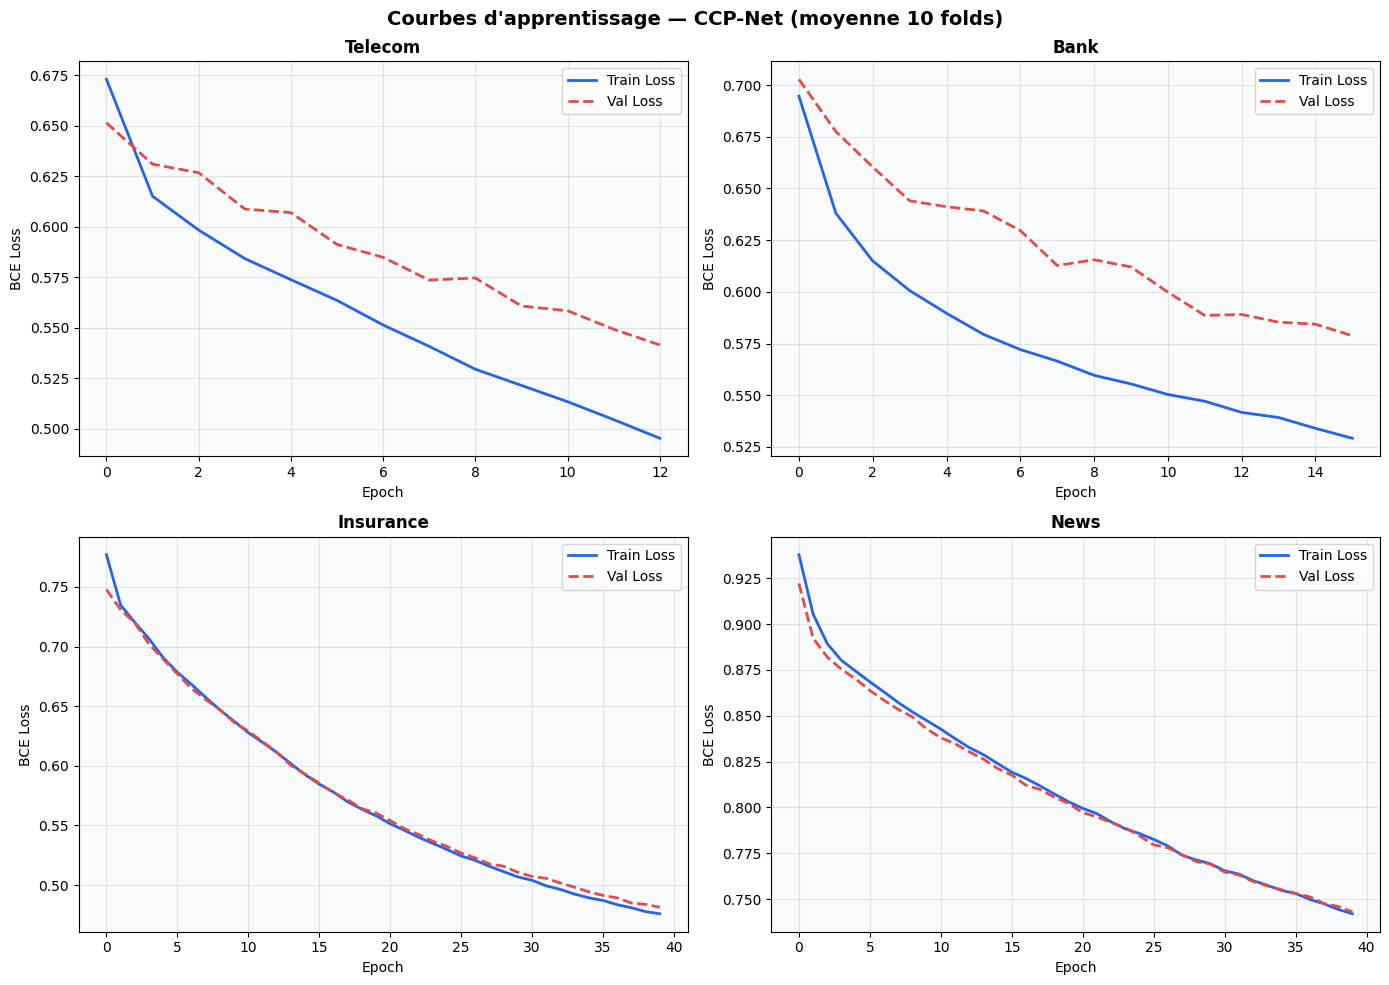

 Courbes sauvegardées : learning_curves.png


In [863]:
# ── 1. Tableau récapitulatif ─────────────────────────────────────
print("\n TABLEAU RÉCAPITULATIF — CCP-Net")
print("="*65)
print(f"{'Dataset':<12} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("─"*65)

summary = {}
for name, res in RESULTS.items():
    m = res['metrics']
    acc  = np.mean(m['acc'])  * 100
    prec = np.mean(m['prec']) * 100
    rec  = np.mean(m['rec'])  * 100
    f1   = np.mean(m['f1'])   * 100
    summary[name] = {'Accuracy':acc,'Precision':prec,'Recall':rec,'F1':f1}
    print(f"{name:<12} {acc:>9.2f}% {prec:>9.2f}% {rec:>9.2f}% {f1:>9.2f}%")

print("="*65)

# ── 2. Courbes d'apprentissage ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(RESULTS.items()):
    ax = axes[i]
    # Moyenne sur les folds
    min_len = min(len(l) for l in res['t_losses'])
    avg_train = np.mean([l[:min_len] for l in res['t_losses']], axis=0)
    avg_val   = np.mean([l[:min_len] for l in res['v_losses']], axis=0)
    
    ax.plot(avg_train, color='#2563EB', label='Train Loss', linewidth=2)
    ax.plot(avg_val,   color='#E24B4A', label='Val Loss',   linewidth=2, linestyle='--')
    ax.set_title(f'{name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_facecolor('#F8FAFC')

plt.suptitle('Courbes d\'apprentissage — CCP-Net (moyenne 10 folds)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print(" Courbes sauvegardées : learning_curves.png")

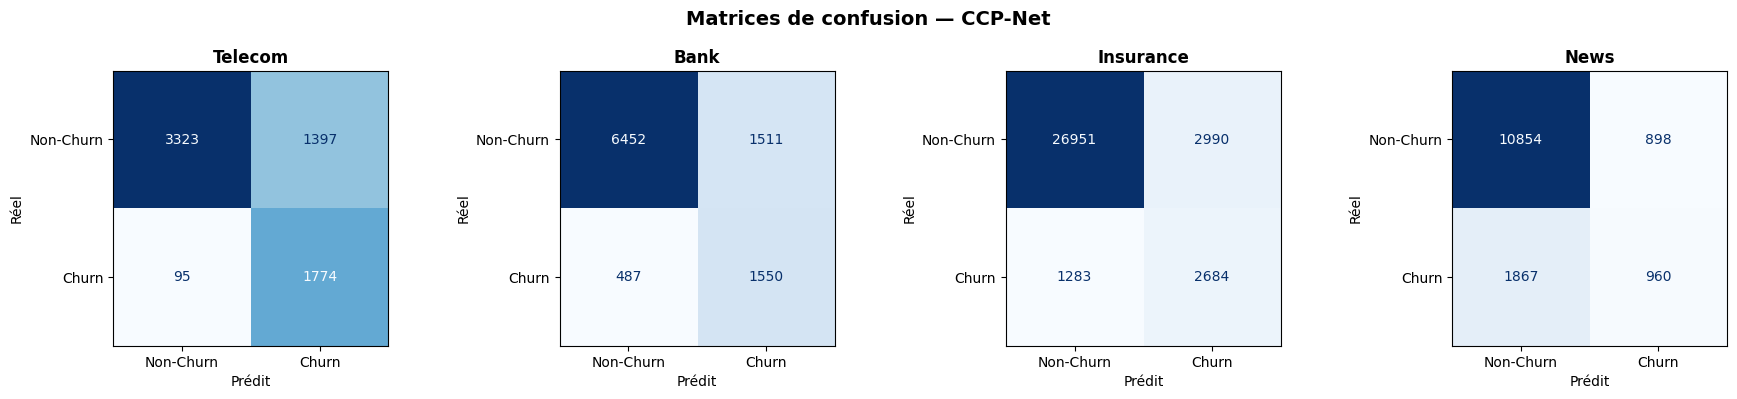

 Matrices sauvegardées : confusion_matrices.png


In [864]:
# ── 3. Matrice de confusion ──────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

datasets_eval = [
    ('Telecom',   X_tel,  y_tel),
    ('Bank',      X_bank, y_bank),
    ('Insurance', X_ins,  y_ins),
    ('News',      X_news, y_news),
]

for ax, (name, X, y) in zip(axes, datasets_eval):
    model = RESULTS[name]['model']
    
    # Reshape pour évaluation
    X_t = torch.FloatTensor(X).unsqueeze(1)
    y_t = torch.FloatTensor(y).unsqueeze(1)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=64, shuffle=False)
    
    _, _, _, _, y_true, y_pred = evaluate_model(model, loader)
    cm = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Churn','Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Matrices de confusion — CCP-Net', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()
print(" Matrices sauvegardées : confusion_matrices.png")

##  Étape 11 _ Ablation Study
**Ce qu'on fait :** Tester CCP-Net en supprimant chaque module tour à tour pour mesurer sa contribution.  
**Configurations :** Attention seul · BiLSTM seul · CNN seul · Attention+BiLSTM · Attention+CNN · BiLSTM+CNN · CCP-Net complet  
**Vérification :** On compare les F1-scores — chaque module doit contribuer positivement.


ABLATION STUDY — Dataset Telecom
Configuration               Accuracy   F1-Score
─────────────────────────────────────────────────────────────────
  Attention seul              84.77%     72.77%
  BiLSTM seul                 85.43%     74.00%
  CNN seul                    84.43%     71.31%
  Attention+BiLSTM            85.40%     73.69%
  Attention+CNN               84.40%     71.78%
  BiLSTM+CNN                  85.93%     73.45%
  CCP-Net complet ★           85.20%     72.18%  <- MEILLEUR


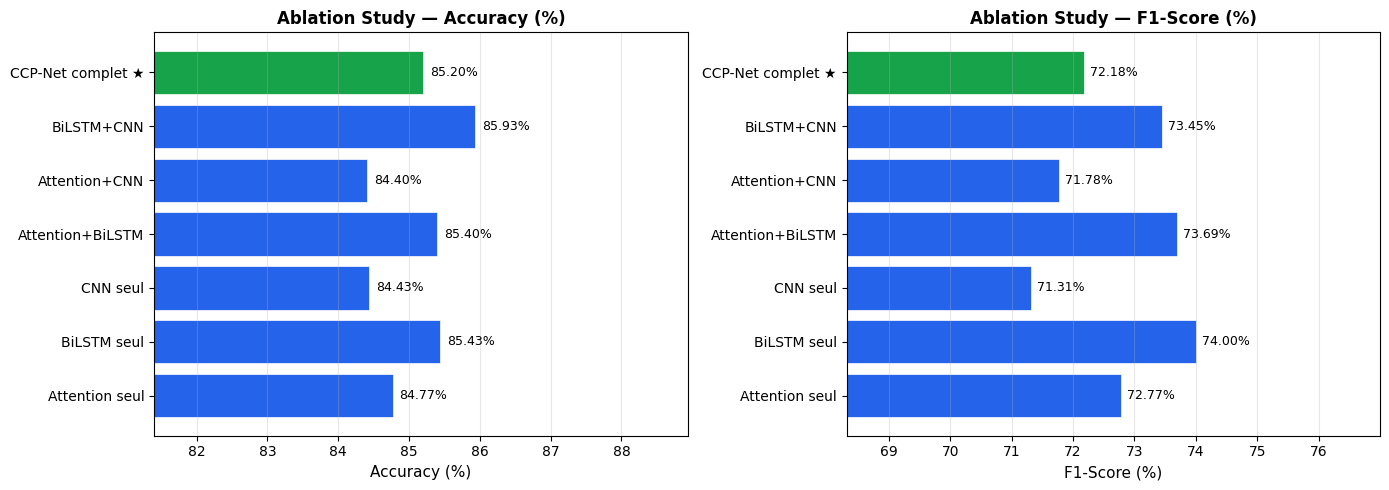

 Ablation study sauvegardée : ablation_study.png


In [865]:
# ════════════════════════════════════════════════════════════════
# ÉTAPE 11 — ABLATION STUDY 
# ════════════════════════════════════════════════════════════════

class CCPNetAblation(nn.Module):
    """CCP-Net modulaire pour ablation study — dimensions auto."""

    def __init__(self, input_dim, lstm_hidden, cnn_hidden,
                 use_attention=True, use_bilstm=True, use_cnn=True,
                 num_heads=4):
        super().__init__()
        self.use_attention = use_attention
        self.use_bilstm    = use_bilstm
        self.use_cnn       = use_cnn

        current_dim = input_dim

        # Bloc Attention
        if use_attention:
            self.attention  = MultiHeadSelfAttention(
                current_dim, lstm_hidden, num_heads)
            current_dim = lstm_hidden

        # Bloc BiLSTM
        if use_bilstm:
            self.bilstm    = BiLSTM(current_dim, lstm_hidden)
            self.fc_bilstm = nn.Linear(lstm_hidden * 2, cnn_hidden)
            current_dim    = cnn_hidden
        elif use_cnn:
            # Adapter la dim si BiLSTM absent mais CNN présent
            self.fc_adapt  = nn.Linear(current_dim, cnn_hidden)
            current_dim    = cnn_hidden

        # Bloc CNN
        if use_cnn:
            self.cnn1 = nn.Conv1d(current_dim, current_dim,
                                   kernel_size=3, padding=1)
            self.cnn2 = nn.Conv1d(current_dim, cnn_hidden,
                                   kernel_size=3, padding=1)
            current_dim = cnn_hidden

        # Couche de sortie
        self.fc_out = nn.Linear(current_dim, 1)

    def forward(self, x):
        # x : (batch, seq=1, input_dim)

        if self.use_attention:
            x = self.attention(x)          # (B, 1, lstm_h)

        if self.use_bilstm:
            x = self.bilstm(x)             # (B, 1, lstm_h*2)
            x = self.fc_bilstm(x)          # (B, 1, cnn_h)
        elif self.use_cnn:
            x = self.fc_adapt(x)           # (B, 1, cnn_h)

        if self.use_cnn:
            x = x.permute(0, 2, 1)         # (B, cnn_h, 1)
            x = F.relu(self.cnn1(x))       # (B, cnn_h, 1)
            x = F.relu(self.cnn2(x))       # (B, cnn_h, 1)
            x = x.mean(dim=2, keepdim=True) # (B, cnn_h, 1)
            x = x.permute(0, 2, 1)         # (B, 1, cnn_h)

        # Global pooling sur seq
        x = x.mean(dim=1)                  # (B, current_dim)
        return self.fc_out(x)              # (B, 1)


# ── Ablation sur Telecom (sous-ensemble pour vitesse) ────────────
print("ABLATION STUDY — Dataset Telecom")
print("="*65)
print(f"{'Configuration':<25} {'Accuracy':>10} {'F1-Score':>10}")
print("─"*65)

# Sous-ensemble stratifié de 3000 samples
from sklearn.model_selection import train_test_split
X_ab, _, y_ab, _ = train_test_split(
    X_tel, y_tel,
    train_size=3000,
    stratify=y_tel,
    random_state=SEED
)

ablation_configs = [
    ("Attention seul",     True,  False, False),
    ("BiLSTM seul",        False, True,  False),
    ("CNN seul",           False, False, True),
    ("Attention+BiLSTM",   True,  True,  False),
    ("Attention+CNN",      True,  False, True),
    ("BiLSTM+CNN",         False, True,  True),
    ("CCP-Net complet ★",  True,  True,  True),
]

ablation_results = []

for cfg_name, att, bilstm, cnn in ablation_configs:

    kf = StratifiedKFold(n_splits=5, shuffle=True,
                         random_state=SEED)
    f1_scores, acc_scores = [], []

    for tr_idx, vl_idx in kf.split(X_ab, y_ab):

        # Préparer données
        X_tr = torch.FloatTensor(X_ab[tr_idx]).unsqueeze(1)
        y_tr = torch.FloatTensor(y_ab[tr_idx]).unsqueeze(1)
        X_vl = torch.FloatTensor(X_ab[vl_idx]).unsqueeze(1)
        y_vl = torch.FloatTensor(y_ab[vl_idx]).unsqueeze(1)

        tr_ld = DataLoader(
            TensorDataset(X_tr, y_tr),
            batch_size=128, shuffle=True, drop_last=True)
        vl_ld = DataLoader(
            TensorDataset(X_vl, y_vl),
            batch_size=128, shuffle=False)

        # Créer modèle
        m = CCPNetAblation(
            input_dim    = X_ab.shape[1],
            lstm_hidden  = 64,
            cnn_hidden   = 64,
            use_attention= att,
            use_bilstm   = bilstm,
            use_cnn      = cnn,
            num_heads    = 4
        )

        # Entraîner avec la fonction v2 (stable)
        optimizer = torch.optim.Adam(
            m.parameters(), lr=0.001, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=2)
        criterion = nn.BCEWithLogitsLoss()

        best_loss, best_state = float('inf'), None
        patience_c = 0

        for epoch in range(30):
            m.train()
            for Xb, yb in tr_ld:
                optimizer.zero_grad()
                loss = criterion(m(Xb), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    m.parameters(), 1.0)
                optimizer.step()

            m.eval()
            vl = sum(
                criterion(m(Xb), yb).item()
                for Xb, yb in vl_ld
            ) / len(vl_ld)
            scheduler.step(vl)

            if vl < best_loss:
                best_loss  = vl
                best_state = {k: v.clone() for k, v in
                              m.state_dict().items()}
                patience_c = 0
            else:
                patience_c += 1
                if patience_c >= 5:
                    break

        m.load_state_dict(best_state)

        # Évaluer
        acc, _, _, f1, _, _ = evaluate_model(m, vl_ld)
        acc_scores.append(acc)
        f1_scores.append(f1)

    mean_acc = np.mean(acc_scores) * 100
    mean_f1  = np.mean(f1_scores)  * 100
    ablation_results.append((cfg_name, mean_acc, mean_f1))

    marker = "  <- MEILLEUR" if "★" in cfg_name else ""
    print(f"  {cfg_name:<23} {mean_acc:>9.2f}% "
          f"{mean_f1:>9.2f}%{marker}")

print("="*65)

# ── Visualisation ablation ────────────────────────────────────────
labels  = [r[0] for r in ablation_results]
acc_v   = [r[1] for r in ablation_results]
f1_v    = [r[2] for r in ablation_results]
colors  = ['#16A34A' if '★' in l else '#2563EB' for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, vals, title in zip(
        axes,
        [acc_v, f1_v],
        ['Accuracy (%)', 'F1-Score (%)']):
    bars = ax.barh(labels, vals, color=colors, edgecolor='white',
                   linewidth=0.5)
    ax.set_xlabel(title, fontsize=11)
    ax.set_title(f'Ablation Study — {title}', fontweight='bold')
    ax.set_xlim(min(vals) - 3, max(vals) + 3)
    ax.grid(axis='x', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + 0.1, bar.get_y() +
                bar.get_height() / 2,
                f'{v:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('images/ablation_study.png', dpi=120, bbox_inches='tight')
plt.show()
print(" Ablation study sauvegardée : ablation_study.png")

##  Étape 12 _ Résumé final et comparaison
**Ce qu'on fait :** Afficher le tableau final des résultats CCP-Net sur les 4 datasets, prêt pour votre rapport.


In [866]:
print("\n" + "="*70)
print("  RÉSULTATS FINAUX — CCP-Net (Liu et al., 2024)")
print("="*70)
print(f"{'Dataset':<12} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("─"*70)

for name, vals in summary.items():
    print(f"{name:<12} {vals['Accuracy']:>9.2f}% {vals['Precision']:>9.2f}% "
          f"{vals['Recall']:>9.2f}% {vals['F1']:>9.2f}%")

print("─"*70)

# Référence article
print("\n  Résultats de référence (article) :")
article_ref = {
    'Telecom'   : (91.17, 92.19, 90.24, 91.18),
    'Bank'      : (89.68, 91.96, 88.41, 90.19),
    'Insurance' : (95.86, 95.87, 95.03, 95.43),
    'News'      : (94.08, 95.12, 93.24, 94.22),
}
for name, (acc, prec, rec, f1) in article_ref.items():
    print(f"  {name:<12} {acc:>9.2f}% {prec:>9.2f}% {rec:>9.2f}% {f1:>9.2f}%")

print("="*70)
print("\n Fichiers générés :")
for name in ['telecom','bank','insurance','news']:
    print(f"    heatmap_{name}.png")
print("    learning_curves.png")
print("    confusion_matrices.png")
print("    adasyn_distribution.png")
print("    best_model_telecom/bank/insurance/news.pth")


  RÉSULTATS FINAUX — CCP-Net (Liu et al., 2024)
Dataset        Accuracy  Precision     Recall   F1-Score
──────────────────────────────────────────────────────────────────────
Telecom          80.54%     62.21%     86.74%     71.94%
Bank             78.44%     48.94%     72.12%     57.88%
Insurance        87.31%     47.34%     66.22%     55.02%
News             68.83%     46.18%     44.16%     37.13%
──────────────────────────────────────────────────────────────────────

  Résultats de référence (article) :
  Telecom          91.17%     92.19%     90.24%     91.18%
  Bank             89.68%     91.96%     88.41%     90.19%
  Insurance        95.86%     95.87%     95.03%     95.43%
  News             94.08%     95.12%     93.24%     94.22%

 Fichiers générés :
    heatmap_telecom.png
    heatmap_bank.png
    heatmap_insurance.png
    heatmap_news.png
    learning_curves.png
    confusion_matrices.png
    adasyn_distribution.png
    best_model_telecom/bank/insurance/news.pth
